# Dark Matter indirect search analysis with Gammapy

This tutorial covers a whole pipeline analysis of indirect search of dark matter using Gammapy. 

we encourage to check tutorials XXXX and XXX for getting the basics about the Dark Matter module and how to handle data.

In this example we will make an analysis with simulated dat from the dwarf galaxy Draco follwing a 3D approach (using spatial and spectral data, not only spectral like in 1D analysis. For more details about the difference between 1D and 3D please go to tutotial XXX.)

Hence, the steps to follow in this tutorial are:
1. Data: Real Data or Simulated. In this ase will be the second option.
2. Run the executions.
3. Analysis products (profile likelihood limits, limits, brazilian plots)

## Setup

In [295]:
from gammapy.data import Observation
from gammapy.datasets import MapDataset, SpectrumDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker
)
from gammapy.maps import MapAxis, WcsGeom, WcsNDMap, RegionGeom
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel,
)
from gammapy.astro.darkmatter import (
    DarkMatterDecaySpectralModel,
    profiles,
    JFactory

)
from gammapy.modeling import Fit
from gammapy.estimators import ParameterEstimator

from regions import CircleSkyRegion

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt


## 1. Data

For this tutorial we will simulate observations of 500 hours of the **Draco dwarf spheroidal galaxy** using CTA-North IRFs (prod5 configuration), obtaining the counts with an Monte Carlo approach. Additionally, we are going to consider that the data follows an Einasto profile and we are going to study the case of Decay with channel b (Boson).

**For further detail in this step or if you want to use Real Data please check the tutorial XXX.**

In [296]:
# Source coordinates
draco_pos = SkyCoord(ra=260.05167 * u.deg, dec=57.915 * u.deg, frame="icrs")
draco_dist = 76 * u.kpc

# Location coordinates, i.e CTA-North
cta_norte = EarthLocation(lat=28.762 * u.deg, lon=-17.89 * u.deg, height=2200 * u.m)  

# Observation start time
obs_time = Time("2025-06-17 01:00:00")  # UTC

altaz = AltAz(obstime=obs_time, location=cta_norte)
draco_altaz = draco_pos.transform_to(altaz)

# Altitude and zenith angle
altitude = draco_altaz.alt.deg
zenith_angle = 90 - altitude

print(f"Altitude: {altitude:.2f}°")
print(f"Zenith angle: {zenith_angle:.2f}°")

Altitude: 60.82°
Zenith angle: 29.18°


In [297]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15) 
#the reconstructed energy axis, used for the final map and counts (i.e. what the telescope measures).
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
#the true energy axis, used internally for the IRFs (e.g. effective area, energy dispersion), since the instrument's response is defined in terms of the true photon energy before any reconstruction effects.
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

# Geometry map we are going to work with
geom_draco = WcsGeom.create(
    binsz=0.1, # Pixel size
    skydir=draco_pos, # Sky position of the target, center of the map
    width=3.0, # Width of the map (i.e 3x3 map)          
    frame="icrs", # Coordinates system
    axes=[energy_reco] 
)

In [298]:
# DM Spatial distribution 
spatial_model = PointSpatialModel(
    lon_0=draco_pos.ra,
    lat_0=draco_pos.dec,
    frame="icrs"
)

> **Note:** Computing these spectra requires the Gammapy datasets to be 
> downloaded and the `GAMMAPY_DATA` environment variable to be set. 
> Please follow the instructions at 
> https://docs.gammapy.org/dev/getting-started/index.html#recommended-setup 
> before running the cells below.

In [299]:
#import os
#os.environ["GAMMAPY_DATA"] = "PATH/gammapy-data"

In [300]:
# DM spectral distribution

# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV

r_s = 0.91 * u.kpc # Scale radius
rho_s = 1.3e7 * (u.M_sun / u.kpc**3) # Scale density
rho_s_GeV = rho_s.to(u.GeV / u.cm**3, equivalencies=u.mass_energy()) # Units conversion

# Define the DM profile. Check profiles.DMProfile.__subclasses__() for more profiles
draco_profile = profiles.EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV
)

# Jfactor - This can also be calculated with the class JFactory, but we set the value for simplicity. You can look for it in dedicated papers.
# for calculating the JFactory see Tutorial XXXX

dfactory = JFactory(
    geom=geom_draco, # Geometry map
    profile=draco_profile, # Chosen density profile
    distance=draco_dist, # Target distance
    annihilation = False # Set if it is annihilation (true) or decay (false)
)

# Computation of the J factor
dfact_draco = dfactory.compute_jfactor() 

# Define a region of interest (i.e., 0.1 deg circle)
sky_reg = CircleSkyRegion(center=draco_pos, radius=0.1 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_draco.wcs)

# Integration of DFactor within that region
total_dfact = pix_reg.to_mask().multiply(dfact_draco).sum()

spectral_model = DarkMatterDecaySpectralModel(
    mass=massDM,
    channel=channel, 
    jfactor=total_dfact)

The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


In [301]:
# Combined model
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="draco-dm"
)

In [302]:
# Background model
bkg_model = FoVBackgroundModel(dataset_name="dataset-simu-draco")

In [303]:
# Load CTA Prod5 IRFs
irf_path = r"/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/IRFs/cta/prod5-v0.1/bcf/North_z20_N_50h/Prod5-North-20deg-NorthAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irfs = load_irf_dict_from_file(irf_path)

# Create the Observation: 500 hours of livetime
livetime = 500 * u.h
obs = Observation.create(
    pointing=draco_pos, 
    livetime=livetime, 
    irfs=irfs, 
    reference_time=obs_time
)

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/gammapy/data/observations.py:303: GammapyDeprecationWarning: Pointing will be required to be provided as FixedPointingInfo
  warnings.warn(


In [304]:
# Dataset creation
# Create an empty MapDataset
empty = MapDataset.create(geom=geom_draco, name="dataset-simu-draco", energy_axis_true=energy_true)

# Setup Maker to calculate exposure, background, PSF, and energy dispersion
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])

# Safe mask
maker_safe_mask = SafeMaskMaker(
    methods=["offset-max"], 
    offset_max=2.5 * u.deg)

# Run the maker and attach models
dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Attach the DM model and a Field-of-View background model
dataset.models = Models([model_simu, bkg_model])

In [ ]:
# Counts simulation
aux_dataset = dataset
dataset_mc = aux_dataset

# Sample Poisson fluctuations around the prediction
# random_state fixes the seed for reproducibility, but it may be random
dataset_mc.fake(random_state=42) 

print("=== MC Observation ===")
# We do not expect the same counts since the statistical noise is introduced
print(f"Predicted counts : {dataset_mc.npred().data.sum():.2f}")
print(f"Simulated counts : {dataset_mc.counts.data.sum()}")

=== MC Observation ===
Predicted counts : 10761511.85
Simulated counts : 10757646.0


In [334]:
print(dataset_mc.models.names)
print(dataset.models.names)

['draco-dm', 'dataset-simu-draco-bkg']
['draco-dm', 'dataset-simu-draco-bkg']


/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encou

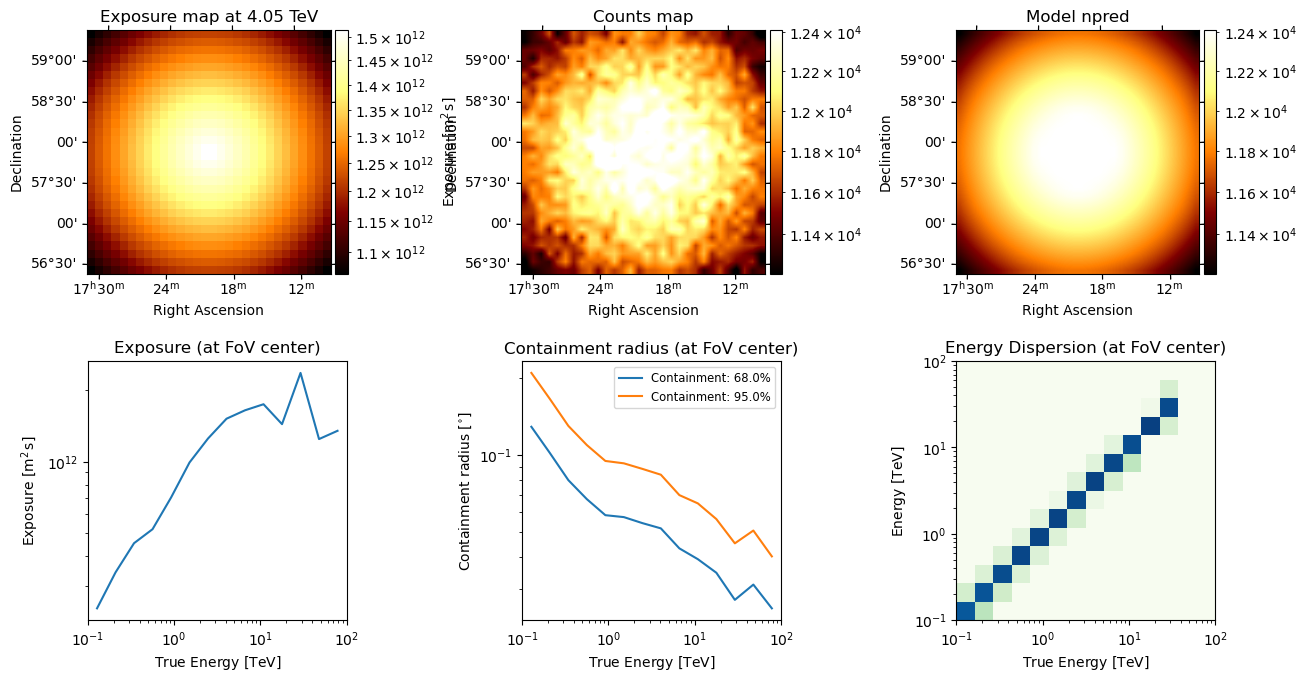

In [335]:
dataset_mc.peek()

## 2. From Dataset to Upper Limits

Now that we have a simulated dataset (MC, in this case), we proceed through the standard analysis pipeline: fit the model, inspect the likelihood profile, and derive the upper limit on the DM annihilation cross section.


Before fitting, we need to decide which parameter(s) of our model are allowed to vary, and which remain fixed.

In a dark matter annihilation search, the physical quantity we want to constrain is the **velocity-averaged annihilation cross section**, ⟨σv⟩. This is the parameter that directly controls the overall amplitude of the predicted gamma-ray signal:

$$\Phi_{\rm ann} \propto \langle\sigma v\rangle \cdot J \cdot \int \frac{dN}{dE}\,dE$$

In `DarkMatterAnnihilationSpectralModel`, ⟨σv⟩ is implemented as the **`scale`** parameter: a multiplicative normalization factor on top of a reference cross section (by default, the thermal relic value, ~3×10⁻²⁶ cm³ s⁻¹). Setting `scale = 1` reproduces the thermal relic prediction; `scale = 0.1` means a cross section ten times smaller, and so on.

All other parameters of the model — the **DM mass** (`mass`), the **annihilation channel**, and the **J-factor** — are kept **fixed** during the fit. This is standard practice in indirect detection analyses:

- **Mass and channel** are scanned externally (we repeat the fit for each 
  mass/channel combination to build the exclusion curve), not fitted 
  simultaneously with σv. Fitting them together would be poorly 
  constrained and physically less meaningful — we want a limit *for each* 
  assumed DM model, not a best-fit DM model.
- **The J-factor** is an external astrophysical input from stellar 
  kinematics (Section 1), not something the gamma-ray data alone can 
  constrain.

The background normalization is typically also left free, so that the fit can absorb any background mismodeling — this protects the DM limit from being artificially tightened or loosened by an imperfect background model.


The logic for the decay case is analogous to annihilation, but the 
physical quantity of interest is different.

For dark matter **decay**, the expected gamma-ray flux is:

$$\Phi_{\rm dec} \propto \frac{1}{\tau_\chi} \cdot D \cdot \int \frac{dN}{dE}\,dE$$

Here the free parameter we want to constrain is the **DM lifetime**, 
τ_χ, rather than a cross section. Note that τ_χ appears in the 
**denominator**: a *longer* lifetime means *slower* decay and therefore 
a *fainter* signal — the opposite scaling from the annihilation case, 
where a larger σv means a brighter signal.

In `DarkMatterDecaySpectralModel`, this is also implemented via a 
**`scale`** parameter, but here it multiplies the **inverse lifetime** 
(the decay rate 1/τ_χ) rather than the cross section. Because of this 
inverse relationship:

- A **lower limit** on τ_χ corresponds to an **upper limit** on the decay 
  rate (1/τ_χ), which is what is actually constrained by a non-detection.
- In practice, Gammapy still reports an upper limit on `scale`, which 
  you then convert to a *lower* limit on τ_χ:

$$\tau_\chi^{\rm limit} = \frac{\tau_{\chi,\,\rm ref}}{{\rm scale}_{\rm UL}}$$

As before, the **mass** and **channel** are scanned externally and kept 
fixed during each individual fit, and the **D-factor** (not the J-factor!) 
is a fixed external input from the astrophysical analysis (Section 1).


The fit adjusts all free parameters (σv, background normalization, ...) to maximize the likelihood given the simulated counts. Note that the best-fit value of σv may be negative or close to zero if no signal is present — this is expected and not unphysical, since the optimizer is simply finding the best statistical match to the data.

## Fitting the Model

With the simulated dataset in hand, we now fit our dark matter model to the (simulated) data. Gammapy's `Fit` class provides a unified interface to several optimization backends; by default it uses 
[iminuit](https://iminuit.readthedocs.io/), a Python wrapper around the MINUIT2 C++ library originally developed at CERN, the de facto standard optimizer in high-energy and astroparticle physics. MINUIT performs a maximum-likelihood fit and additionally provides robust parameter errors and covariance estimates via the Hesse and Minos algorithms.

During the fit, the optimizer adjusts all **free** parameters of the model — in our case, `scale` (related to ⟨σv⟩ or 1/τ_χ, depending on whether we are studying annihilation or decay) and the background normalization — to maximize the Poisson likelihood between the observed (or simulated) counts and the model prediction. All other parameters, such as the DM mass, channel, and the source position, remain fixed at their assumed values.

Nevertheless, before fitting, let's check the current status of our model parameters and free up `scale` for the fit.


In [336]:
# Whole dataset
display(dataset_mc.models.to_parameters_table())

model,type,name,value,unit,error,min,max,frozen,link,prior
str22,str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
draco-dm,,scale,9.9525e-07,,1.000e+00,1.000e-12,1.000e-03,False,,
draco-dm,,lon_0,2.6005e+02,deg,1.000e+00,nan,nan,False,,
draco-dm,,lat_0,5.7916e+01,deg,1.000e+00,-9.000e+01,9.000e+01,False,,
dataset-simu-draco-bkg,,tilt,0.0000e+00,,1.000e+00,nan,nan,True,,
dataset-simu-draco-bkg,,norm,1.0000e+00,,1.000e+00,nan,nan,False,,
dataset-simu-draco-bkg,,reference,1.0000e+00,TeV,1.000e+00,nan,nan,True,,


In [337]:
# Just the spectral model
display(spectral_model.parameters.to_table())

type,name,value,unit,error,min,max,frozen,link,prior
str1,str5,float64,str1,float64,float64,float64,bool,str1,str1
,scale,9.9525e-07,,1.000e+00,1.000e-12,1.000e-03,False,,


Check that:

- `scale` (σv for annihilation, or 1/τ_χ for decay) is **free** 
  (`frozen=False`)
- `mass` is **frozen** (`frozen=True`), since it is scanned externally
- The background normalization parameter is **free**

If `scale` shows `frozen=True`, unfreeze it before fitting:

In [339]:
spectral_model.parameters["scale"].frozen = False

Now, let's fit.

In [340]:
fit = Fit()
result = fit.run(datasets=[dataset_mc])

Once the fit has converged, the next steps are to inspect the result, quantify the constraint on our parameter of interest via the likelihood profile, and derive the upper limit.

In [341]:
print(result)
display(dataset.models.to_parameters_table())

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : False
	message    : Optimization failed.
	nfev       : 241
	total stat : -154488699.37

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



model,type,name,value,unit,error,min,max,frozen,link,prior
str22,str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
draco-dm,,scale,9.9525e-07,,nan,1.000e-12,1.000e-03,False,,
draco-dm,,lon_0,2.6005e+02,deg,nan,nan,nan,False,,
draco-dm,,lat_0,5.7916e+01,deg,nan,-9.000e+01,9.000e+01,False,,
dataset-simu-draco-bkg,,tilt,0.0000e+00,,nan,nan,nan,True,,
dataset-simu-draco-bkg,,norm,9.9964e-01,,nan,nan,nan,False,,
dataset-simu-draco-bkg,,reference,1.0000e+00,TeV,nan,nan,nan,True,,


Check the `success` flag and the number of function calls to make sure 
the optimizer converged properly. The parameters table shows the 
best-fit value of `scale` together with its (symmetric) error from the 
Hessian — keep in mind this Gaussian error is often a poor approximation 
for a parameter like σv (or 1/τ_χ) that is physically bounded at zero 
and for which no significant signal is expected.

In this case our flag is `False`. By construction, `scale = 1` corresponds 
to a DM lifetime equal to `LIFETIME_AGE_OF_UNIVERSE` (~4.3×10¹⁷ s, roughly 
the age of the Universe). This is many orders of magnitude **shorter** 
than the lifetimes actually excluded by current observations (typically 
τ ≳ 10²⁵–10²⁸ s), so a fit started at `scale = 1` would predict an 
enormous, completely unphysical gamma-ray flux — far exceeding even the 
background level.

To avoid this, we set a more realistic prior on `scale` before fitting, 
several orders of magnitude below 1, so that the optimizer starts in a 
region of parameter space where the predicted signal is small compared 
to the background, consistent with a non-detection:

In [342]:
spectral_model.scale.value = 1e-6
spectral_model.scale.min = 1e-12
spectral_model.scale.max = 1e-3

There is, however, a subtlety: `dataset.counts` is **fixed** the moment 
`dataset.fake()` is called, representing "what we observed" under 
whatever `scale` was set *at that time*. `dataset.npred()`, on the other 
hand, is recomputed dynamically from the current model parameters every 
time the fit evaluates the likelihood. If the dataset was simulated with 
a value of `scale` very different from the one we now set as the fit's 
starting point, the optimizer begins extremely far from any reasonable 
minimum and can fail to converge — exactly what we just saw.

To fix this, we re-simulate the dataset *after* setting `scale` to the 
above value, so that the simulated counts and the model starting point 
are consistent with one another:

In [344]:
dataset_mc.models = Models([model_simu, bkg_model])
dataset_mc.fake(random_state=42)

print(f"Predicted counts : {dataset_mc.npred().data.sum():.2f}")
print(f"Simulated counts : {dataset_mc.counts.data.sum()}")

Predicted counts : 10843485.90
Simulated counts : 10840108.0


In [345]:
fit = Fit()
result = fit.run(datasets=[dataset_mc])
print(result)
display(dataset.models.to_parameters_table())

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 87
	total stat : -155832127.54

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



model,type,name,value,unit,error,min,max,frozen,link,prior
str22,str1,str9,float64,str3,float64,float64,float64,bool,str1,str1
draco-dm,,scale,1.0067e-06,,5.301e-09,1.000e-12,1.000e-03,False,,
draco-dm,,lon_0,2.6005e+02,deg,8.244e-04,nan,nan,False,,
draco-dm,,lat_0,5.7916e+01,deg,4.378e-04,-9.000e+01,9.000e+01,False,,
dataset-simu-draco-bkg,,tilt,0.0000e+00,,0.000e+00,nan,nan,True,,
dataset-simu-draco-bkg,,norm,9.9927e-01,,3.064e-04,nan,nan,False,,
dataset-simu-draco-bkg,,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,


With a consistent starting point, the fit now converges successfully.

With a successful fit, we now have a best-fit value of `scale` (and its Hessian-based error) for this particular dataset, mass, and channel. 
However, since we expect no significant DM signal, the more meaningful result is not the best-fit value itself but the **upper limit** it implies — which we derive next using the likelihood profile.

### Likelihood profile

The profile shows how the likelihood degrades as `scale` moves away from its best-fit value. We use it both as a sanity check on the fit (the profile should be smooth and roughly parabolic near the minimum) and to read off the upper limit, defined as the value of `scale` at which Δ ln L = 2.71 (95% confidence level for one degree of freedom).

In [362]:
# Scanning range
scale_par = dataset_mc.models["draco-dm"].spectral_model.scale
scale_par.scan_values = np.logspace(-9, -3, 50)  # Range of our scale

profile = fit.stat_profile(
    datasets=[dataset_mc],
    parameter=scale_par,
    reoptimize=True,  # Reoptimize the parameters
)

print(profile.keys())

dict_keys(['draco-dm.spectral.scale_scan', 'stat_scan', 'fit_results'])


In [359]:
profile["stat_scan"]

array([-1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08, -1.55768933e+08, -1.55768933e+08,
       -1.55768933e+08, -1.55768933e+08])

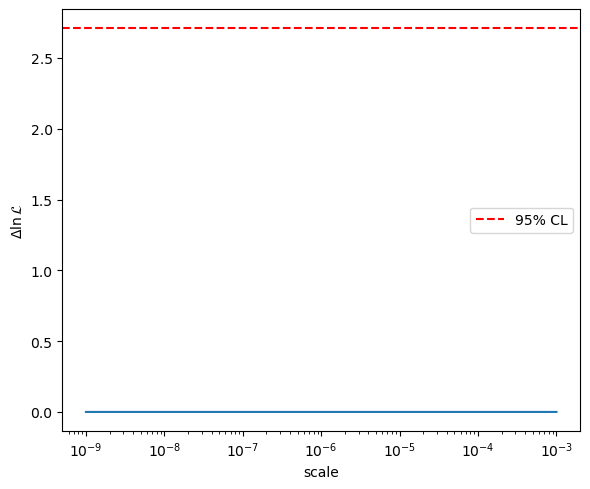

In [361]:
delta_stat = profile["stat_scan"] - profile["stat_scan"].min()

plt.figure(figsize=(6, 5))
plt.plot(profile["draco-dm.spectral.scale_scan"], delta_stat)
plt.axhline(2.71, color="red", linestyle="--", label="95% CL")
plt.xscale("log")
plt.xlabel("scale")
plt.ylabel(r"$\Delta \ln \mathcal{L}$")
plt.legend()
plt.tight_layout()
plt.show()

### Upper limit


`ParameterEstimator` automates the profile-likelihood scan and directly returns the upper limit, without needing to manually inspect the profile each time. This is the value we will translate into a physical upper limit on ⟨σv⟩ (or a lower limit on τ_χ) in the next step.

In [ ]:
estimator = ParameterEstimator(
    n_sigma_ul=2,
    selection_optional=["ul"],
)
result_par = estimator.run(datasets=[dataset], parameter="scale")

scale_ul = result_par["scale_ul"]
print(f"Upper limit on scale: {scale_ul:.3f}")

Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02919597, 57.9157751)> is outside valid IRF map range, using nearest IRF defined within
Position <SkyCoord (ICRS): (ra, dec) in deg
    (255.02919597, 57.9157751)> is outside valid IRF map range, using nearest IRF defined within


Upper limit on scale: nan


Since `scale` is a dimensionless multiplicative factor on top of a reference value, we recover the physical limit by multiplying (for annihilation) or inverting (for decay):

In [320]:
# Annihilation case - Not the case of this tutorial
sigma_v_ref = 3e-26 * u.Unit("cm3 s-1")  # default reference cross section
sigma_v_ul = scale_ul * sigma_v_ref
print(f"Upper limit on <sigma v>: {sigma_v_ul:.2e}")

Upper limit on <sigma v>: nan cm3 / s


In [321]:
# Decay case
tau_ref = spectral_model.LIFETIME_AGE_OF_UNIVERSE
tau_ul = tau_ref / scale_ul
print(f"Lower limit on tau: {tau_ul:.2e}")

Lower limit on tau: nan s


This single (mass, channel) result is the building block for the final 
product of a dark matter search: repeating this whole procedure across a 
grid of masses produces the standard exclusion curve, which we build in 
the next section.